### **Parallelization**

In [1]:
from dotenv import load_dotenv
import os 
load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("API_key is set")
else:
    print("API_KEY is not set")

API_key is set


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


In [3]:
### Pydantic schema

In [4]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    topic : str
    insta : str
    twitter:str
    linkedin : str


In [9]:
def create_insta(state:graph_schema)->graph_schema:
    
    topic = state["topic"]
    post = llm.invoke("what an instagram post about {topic}").content
    state["insta"] = post
    return {"insta":post}

def create_twitter(state:graph_schema)->graph_schema:
    topic = state["topic"]
    post = llm.invoke("what an twitter post about{topic}").content
    state["twitter"] = post
    return {"twitter":post}

def create_linkedin(state:graph_schema)->graph_schema:
    topic = state["topic"]
    post = llm.invoke("what an Linkeding post about {topic}").content
    state["linkedin"] = post
    return {"linkedin":post}

In [10]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("create_insta",create_insta)
graph.add_node("create_twitter",create_twitter)
graph.add_node("create_linkedin",create_linkedin)

graph.add_edge(START,"create_insta")
graph.add_edge(START,"create_twitter")
graph.add_edge(START,"create_linkedin")
graph.add_edge("create_insta",END)
graph.add_edge("create_twitter",END)
graph.add_edge("create_linkedin",END)

parallel_graph = graph.compile()

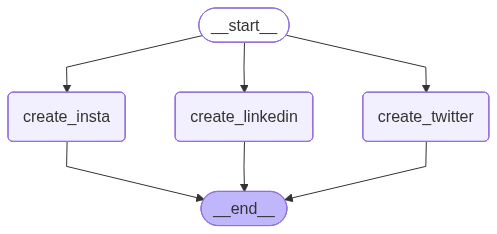

In [11]:
from IPython.display import display,Image

Image(parallel_graph.get_graph().draw_mermaid_png())

In [12]:
parallel_graph.invoke({"topic":"Artificial Intelligence",
                       "insta":"",
                       "twitter":"",
                       "linkedin":""})

{'topic': 'Artificial Intelligence',
 'insta': 'Okay, let\'s craft a versatile Instagram post template that you can easily adapt for any `{topic}`!\n\n---\n\n**Image/Video Idea:**\n*   [A captivating, high-quality photo or short video directly related to {topic}. Think visually appealing, engaging, and relevant. Could be a beautiful shot, a behind-the-scenes glimpse, a graphic with a key stat, or a short engaging clip.]\n\n---\n\n**The Instagram Post:**\n\n**(Start with an emoji or two that sets the tone for {topic})**\n✨💡 Let\'s dive deep into something truly fascinating today: **{Your Topic Here}**! ✨💡\n\n[**Hook/Opening Line - Grab attention!**]\nEver wondered about the magic behind [a specific aspect of {topic}]? Or perhaps you\'re curious about how [another aspect of {topic}] impacts our daily lives? Well, you\'re in the right place!\n\n[**Body Paragraph 1 - Introduce the {topic} and its importance/relevance.**]\n{Topic} isn\'t just a buzzword; it\'s a [describe its nature: moveme